# MATERI

### 1. instalasi libary

In [12]:
!pip install networkx matplotlib

### 2. Struktur data graf dan algoritma

In [21]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}

    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

### 3. fungsi untuk merekonstruksi jalur

In [22]:
def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

### 4. visualisasi dengan networkx dan matplotlib

In [23]:
def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight=weight)
  pos = nx.spring_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, with_labels=True, node_color='Lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len(path) > 1:
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi graf dan jalur terpendek")
  plt.axis('off')
  plt.show()

### 5. penggunaan lengkap

Jarak dari A ke Z: 14
Jalur: A > B > D > E > Z


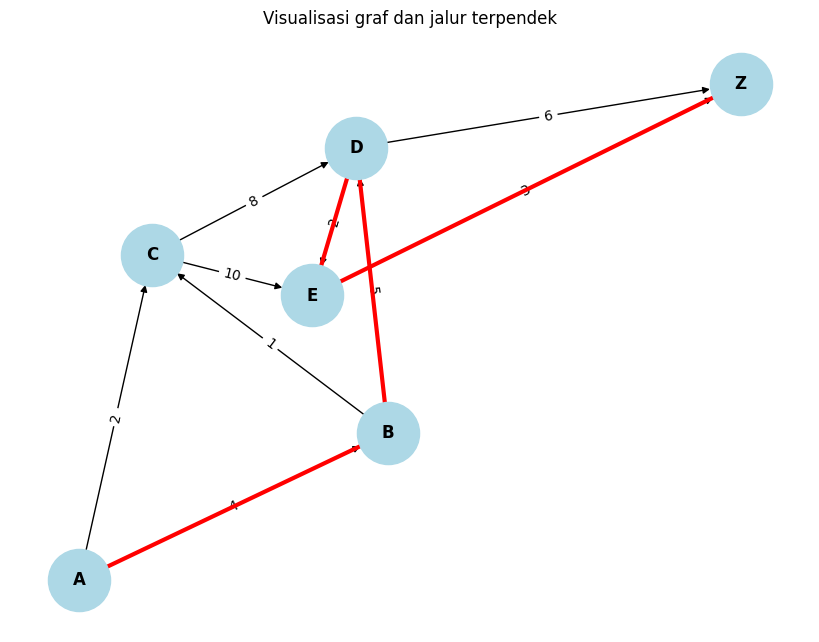

In [ ]:
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' > '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

# LATIHAN/TUGAS

### modifikasi graf agar ada siklus

Jarak dari A ke Z: 14
Jalur: A → B → D → E → Z


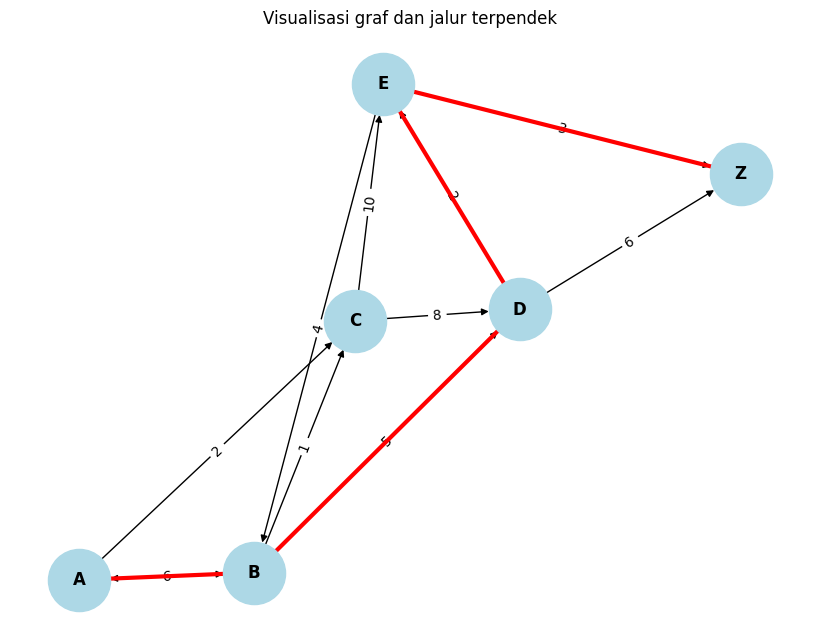

In [8]:
graph_siklus = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5, 'A': 6},  # B → A (siklus pertama)
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'B': 4},            # E → B (siklus kedua)
    'Z': {}
}

dist_siklus, prev_siklus = dijkstra_with_paths(graph_siklus, 'A')
jalur_siklus = get_path(prev_siklus, 'Z')

print(f"Jarak dari A ke Z: {dist_siklus['Z']}")
print(f"Jalur: {' → '.join(jalur_siklus)}")

visualize_graph(graph_siklus, path=jalur_siklus)

### menambah sampul baru

Jarak dari X ke Z: 14
Jalur: X → C → E → Z

Semua jarak dari X:
  X → A: 3
  X → B: 7
  X → C: 1
  X → D: 9
  X → E: 11
  X → Z: 14
  X → X: 0


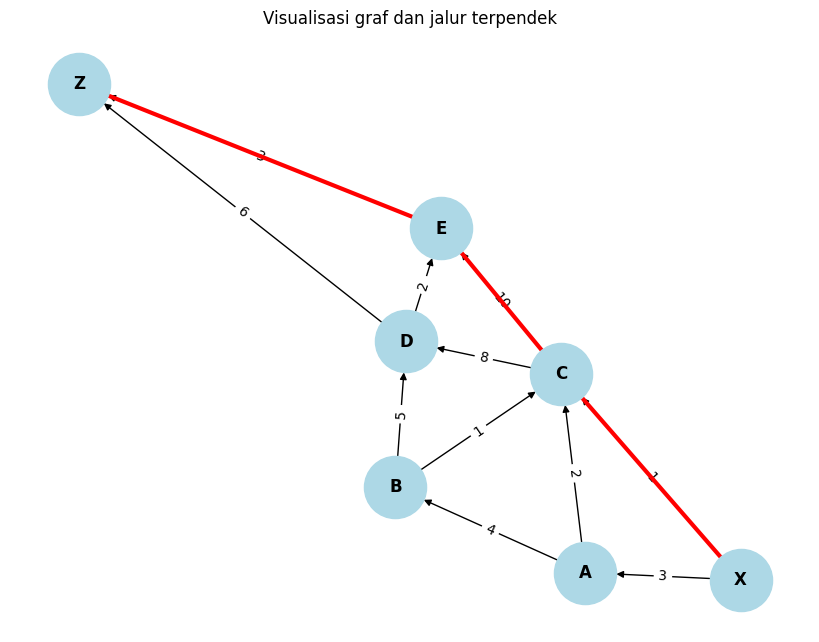

In [10]:
# Graf dengan simpul baru 'X' sebagai titik awal
graph_baru = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {},
    'X': {'A': 3, 'C': 1}  # simpul baru X
}

dist_baru, prev_baru = dijkstra_with_paths(graph_baru, 'X')
jalur_baru = get_path(prev_baru, 'Z')

print(f"Jarak dari X ke Z: {dist_baru['Z']}")
print(f"Jalur: {' → '.join(jalur_baru)}")
print()
print("Semua jarak dari X:")
for simpul, jarak in dist_baru.items():
    print(f"  X → {simpul}: {jarak}")

visualize_graph(graph_baru, path=jalur_baru)